## Causal LLM
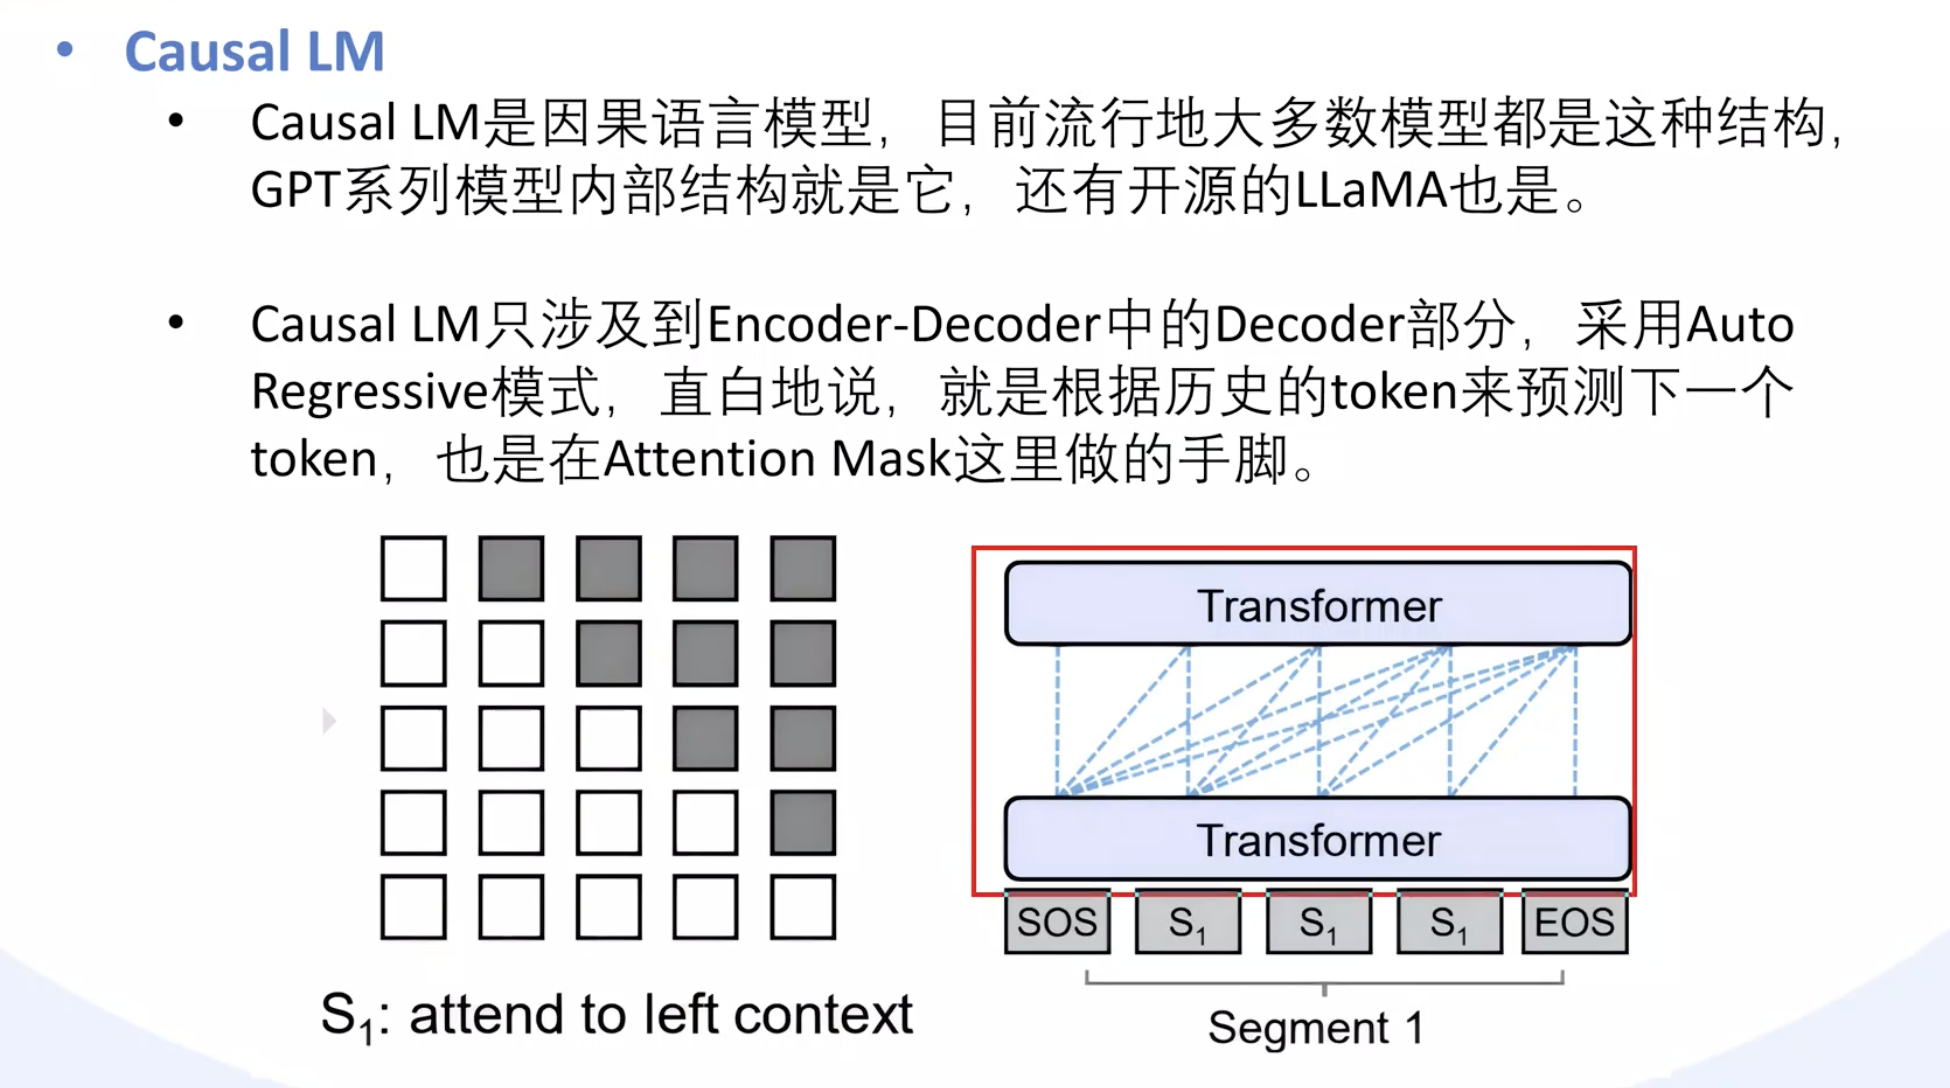

## Prefix LM
不是传统的encoder-decoder，是在同一层，前面一部分是encoder，后一部分是decoder \
也就是前面一部分可以看到前面一部分的全部，后面一部分只能是后续掩码
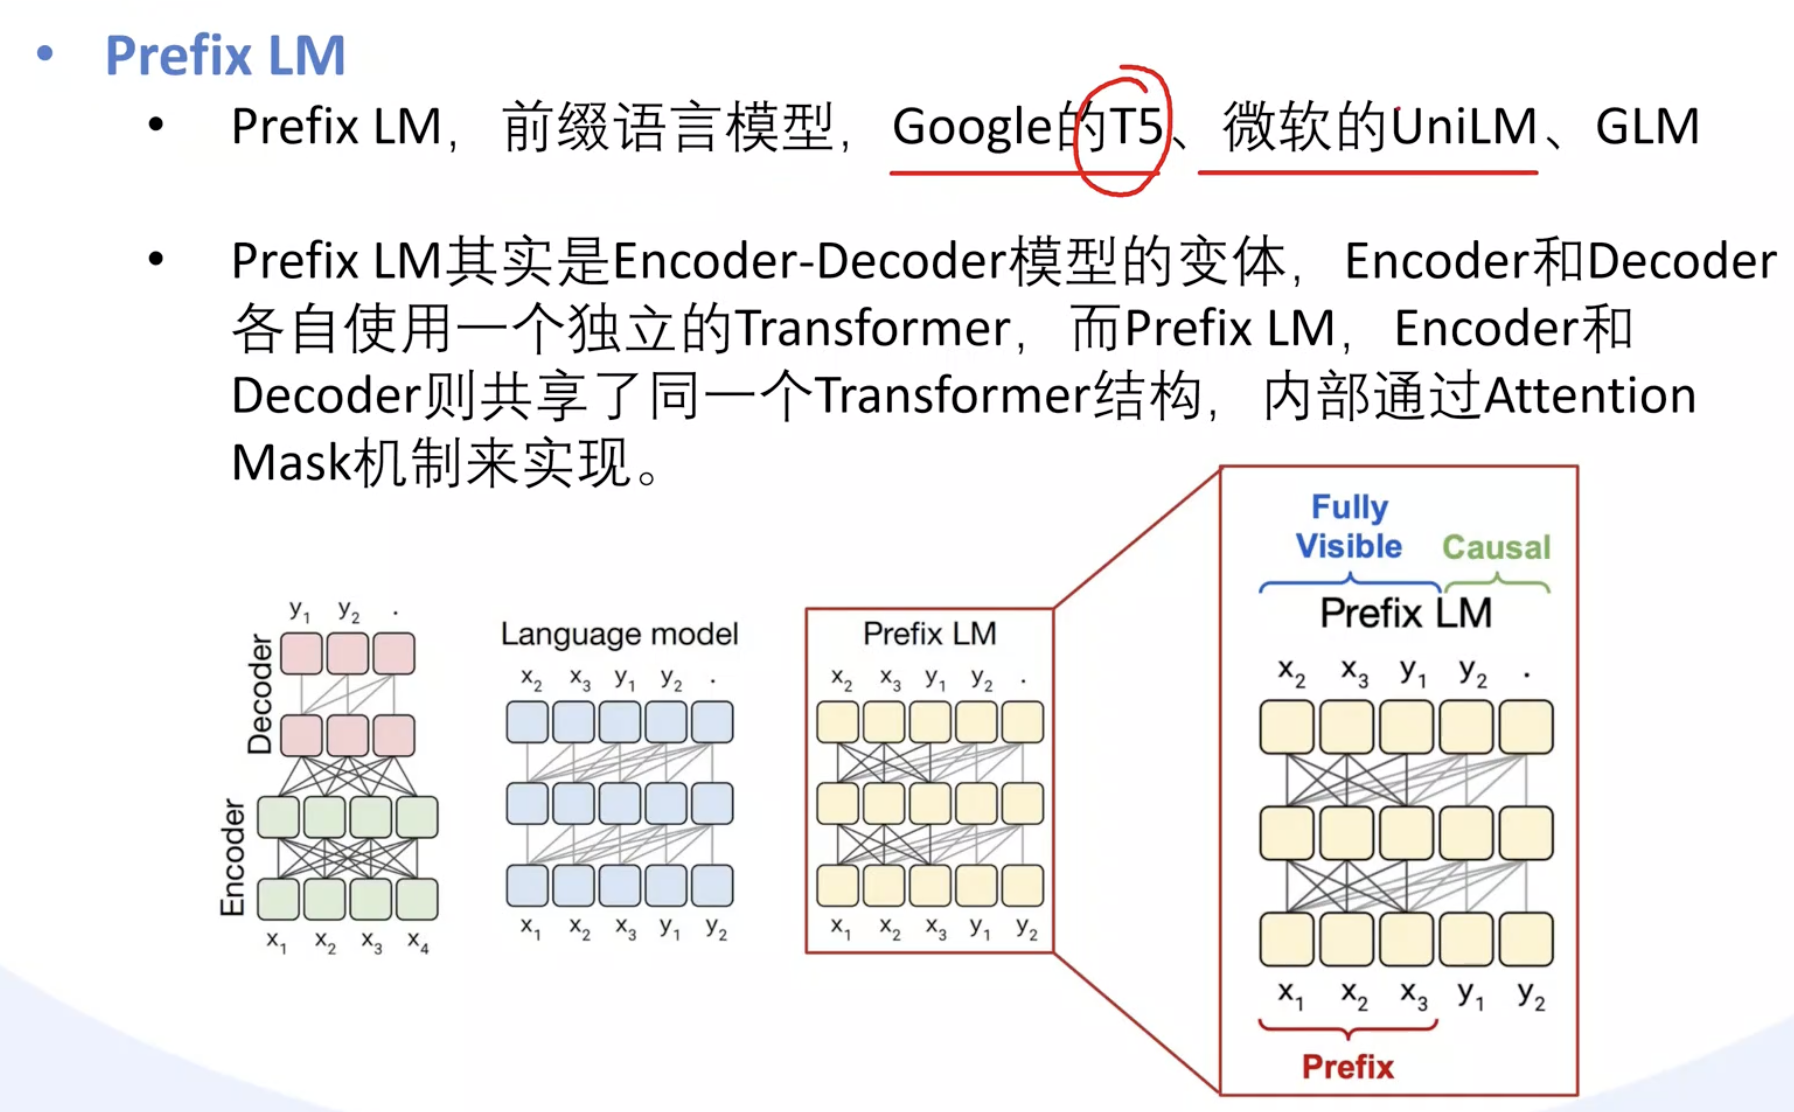

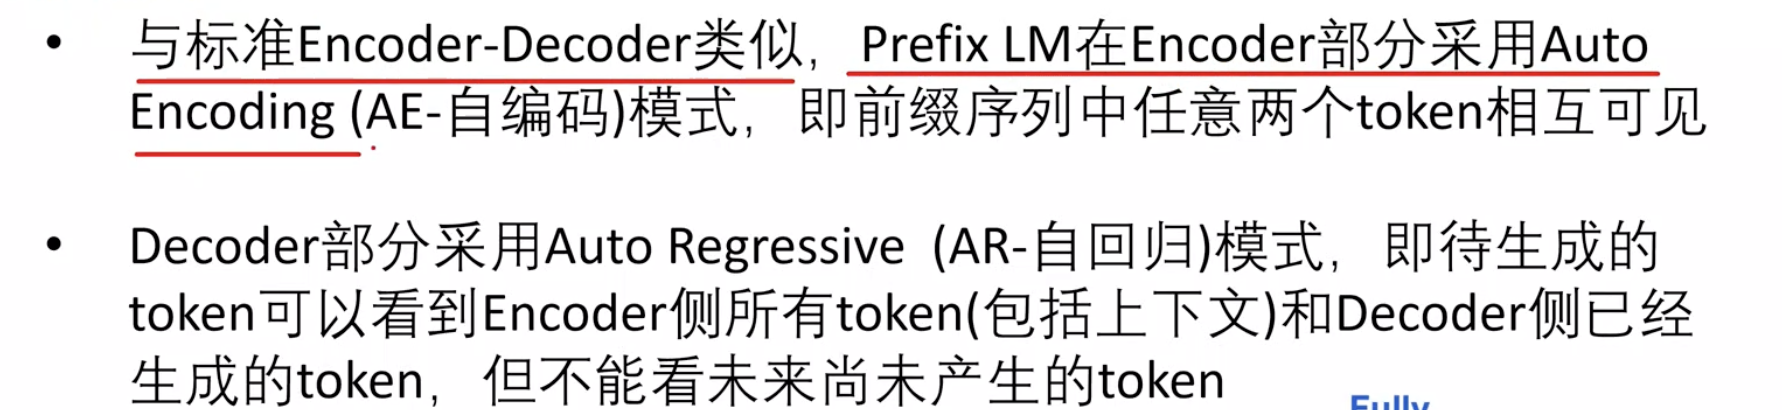

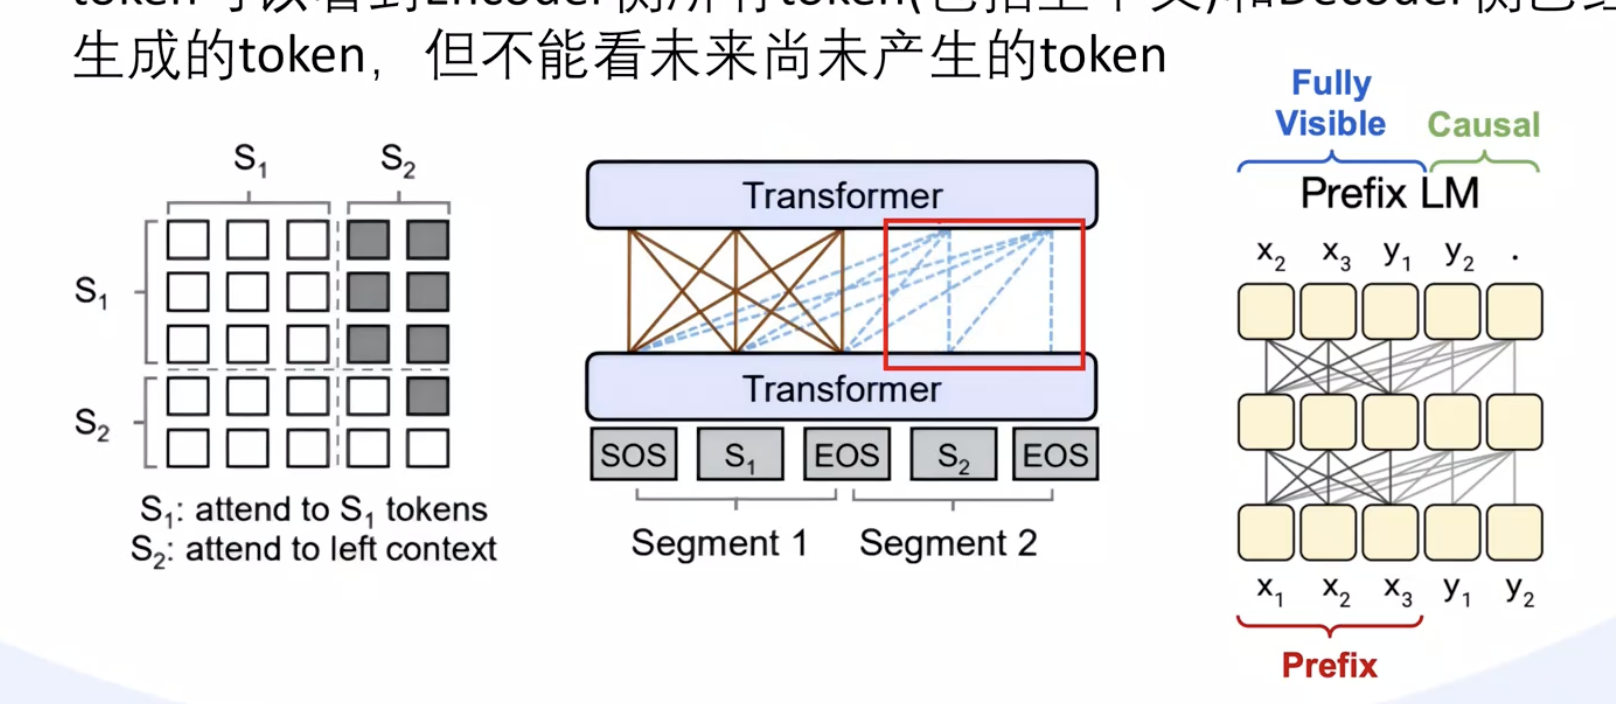

# 准备好预训练的GLM模型

In [2]:
from modelscope.hub.snapshot_download import snapshot_download
import os
from datasets import Dataset,load_dataset
from transformers import AutoTokenizer,AutoModelForCausalLM, \
    DataCollatorForSeq2Seq,TrainingArguments,Trainer
    
model_path = os.path.expanduser("~/models/GLM-Z1-9B-0414")
# snapshot_download(model_id="THUDM/GLM-Z1-9B-0414",
#                   local_dir=model_path,
#                   ignore_file_pattern=".pth")


# 加载分词器

In [3]:
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer

PreTrainedTokenizerFast(name_or_path='/Users/daijunjie/models/GLM-Z1-9B-0414', vocab_size=151329, model_max_length=128000, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'eos_token': '<|endoftext|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|endoftext|>', '[MASK]', '[gMASK]', '[sMASK]', '<sop>', '<eop>', '<|system|>', '<|user|>', '<|assistant|>', '<|observation|>', '<|begin_of_image|>', '<|end_of_image|>', '<|begin_of_video|>', '<|end_of_video|>']}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	151329: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151330: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151331: AddedToken("[gMASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151332: AddedToken("[sMASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, s

In [4]:
input = "你好啊hello, hello"
input_dict = tokenizer(input)
text = tokenizer.decode(input_dict["input_ids"])
text

'你好啊hello, hello'

In [5]:
from transformers import AutoModel,AutoTokenizer,Trainer,TrainingArguments
import torch

model = AutoModel.from_pretrained(model_path,
                                  low_cpu_mem_usage=True,
                                  torch_dtype=torch.half)

ValueError: The checkpoint you are trying to load has model type `glm4` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

In [6]:
query = "如何提高学习效率"
inputs = tokenizer.apply_chat_template([
    {"role":"user",
     "content":query}
],
    add_generation_prompt=True, # 对于这个tokenizer 会在结尾加上一个<|assistant|>
    tokenize=True,
    return_tensors="pt",
    return_dict=True
    )
print('tokenized inputs:',inputs)
print('decoded inputs: ',tokenizer.decode(inputs["input_ids"][0]))
type(inputs)

tokenized inputs: {'input_ids': tensor([[151331, 151333, 151336,    198,  99273,  99224,  98935, 100800, 151337]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}
decoded inputs:  [gMASK]<sop><|user|>
如何提高学习效率<|assistant|>


transformers.tokenization_utils_base.BatchEncoding

# 加载数据集

In [7]:
data_dir = os.path.expanduser("~/datasets/alpaca-gpt4-data-zh")

ds = load_dataset(path=data_dir,split="train")
ds

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 48818
})

In [8]:
from transformers.tokenization_utils_fast import PreTrainedTokenizerFast
def process_func(example,tokenizer:PreTrainedTokenizerFast):
    MAX_LENGTH=256
    # 先获取纯文本的instruction
    instruction = "\n".join([example["instruction"],example["input"]]).strip()
    """
    [gMASK]<sop><|user|> \n{query}      <|assistant|>
    """
    instruction = tokenizer.apply_chat_template(
        [{"role":"user","content":instruction}],
        add_generation_prompt=True,
        # return_tensors="pt",
        return_dict=True)
    # response
    response = tokenizer("\n" + example["output"])
    input_ids = instruction["input_ids"]+response["input_ids"] + [tokenizer.eos_token_id]
    # GLM的掩码 正常给，应该是模型内部进行处理
    attention_mask = instruction["attention_mask"]+response["attention_mask"] + [1]
    # labels
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"] + [tokenizer.eos_token_id]
    
    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
    
    return {
        "input_ids": input_ids,
        "attention_mask":attention_mask,
        "labels": labels
    }
    pass


tokenized_ds = ds.map(process_func,fn_kwargs={"tokenizer":tokenizer})

In [9]:
print(tokenizer.decode(tokenized_ds[0]["input_ids"]))
# print(tokenizer.decode(tokenized_ds[0]["labels"]))
print('labels:')
print(tokenizer.decode( list(filter( lambda x: x!=-100 , tokenized_ds[0]["labels"])) ))

[gMASK]<sop><|user|>
保持健康的三个提示。<|assistant|>
以下是保持健康的三个提示：

1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。

2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。

3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时的睡眠。良好的睡眠有助于减轻压力，促进身体恢复，并提高注意力和记忆力。<|endoftext|>
labels:

以下是保持健康的三个提示：

1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。

2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。

3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时的睡眠。良好的睡眠有助于减轻压力，促进身体恢复，并提高注意力和记忆力。<|endoftext|>
